In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pandas as pd

import torch
import torch.nn as nn

Change working directory

In [ ]:
notebook_path = %pwd

os.chdir(Path(notebook_path).parent.parent.parent)
os.getcwd()

'/home/atleeri/repositories/forecast-electricity-markets'

Load Processed Data

In [ ]:
processed_data_dir = Path('data/processed/')
filepaths = list(processed_data_dir.glob('**/all_samples/*60*.parquet'))
filepaths

[PosixPath('data/processed/opsd-time_series-2020-10-06/time_series_60min_singleindex.parquet')]

In [7]:
filepath = filepaths[0]
df = pd.read_parquet(filepath)
df

,utc_timestamp,cet_cest_timestamp,DE_wind_generation,DE_price_ahead
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,NaN,NaN
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,8852.0,NaN
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,9054.0,NaN
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,9070.0,NaN
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,9163.0,NaN
...,...,...,...,...
50396,2020-09-30 19:00:00+00:00,2020-09-30 20:00:00+01:00,10654.0,49.92
50397,2020-09-30 20:00:00+00:00,2020-09-30 21:00:00+01:00,11836.0,42.79
50398,2020-09-30 21:00:00+00:00,2020-09-30 22:00:00+01:00,12168.0,35.02
50399,2020-09-30 22:00:00+00:00,2020-09-30 23:00:00+01:00,12533.0,34.40


Select Sample

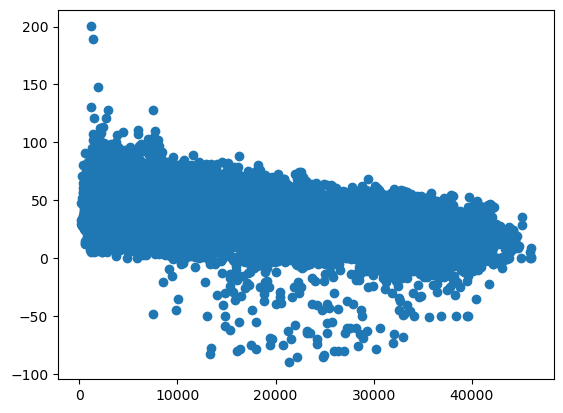

In [8]:
df_sample = df.sample(n=len(df), random_state=2025)
valid_mask = df_sample['DE_wind_generation'].notna() & df_sample['DE_price_ahead'].notna()
plt.scatter(df_sample[valid_mask]['DE_wind_generation'], df_sample[valid_mask]['DE_price_ahead'])

In [9]:
data = df_sample[valid_mask]['DE_price_ahead'].sort_index().values
data

array([56.1 , 51.41, 47.38, ..., 42.79, 35.02, 34.4 ], shape=(17540,))

### Forecast Using Only Price Data

Create Sequences for Seq2Seq Forecasting

In [ ]:
def create_sequences(data, input_len: int = 20, output_len: int = 10, ) -> tuple[np.ndarray, np.ndarray]:
    """Create sequences of data for forecasting

    Args:
        data: data to use for forecasting
        input_len: past elements to use - the length of the sequences
        output_len: number of elements to predict (horizon)
    Returns:
        X: past sequences
        y: labels for prediction

    Raises:
        AssertionError: If sum of input_len and output_len is not smaller than number of data points
    """

    assert len(data) > (input_len + output_len), "Number of data points must be greater than number of data points used in forecast"

    # X is the past data and y is the labels for data to forecast
    X, y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(y)

In [72]:
# use input_len last elements to forecast output_len next elements
X, y = create_sequences(data, input_len=20, output_len=1)

X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)
X,y

(tensor([[56.1000, 51.4100, 47.3800,  ..., 69.9300, 75.0000, 65.8300],
         [51.4100, 47.3800, 47.5900,  ..., 75.0000, 65.8300, 53.8600],
         [47.3800, 47.5900, 51.6100,  ..., 65.8300, 53.8600, 46.4600],
         ...,
         [41.7800, 39.9000, 37.9500,  ..., 60.1400, 72.4300, 55.3400],
         [39.9000, 37.9500, 37.7900,  ..., 72.4300, 55.3400, 49.9200],
         [37.9500, 37.7900, 41.8900,  ..., 55.3400, 49.9200, 42.7900]]),
 tensor([[53.8600],
         [46.4600],
         [42.5000],
         ...,
         [49.9200],
         [42.7900],
         [35.0200]]))

Split Data into Train, Validation, and Test Datasets

In [73]:
train_len = int(0.7*X.shape[0])
val_len = int(0.15*X.shape[0])
test_len = X.shape[0] - train_len - val_len

X_train, X_val, X_test = torch.split(X, [train_len, val_len, test_len])
y_train, y_val, y_test = torch.split(y, [train_len, val_len, test_len])
X_train.shape, X_val.shape, X_test.shape, y_train.shape

(torch.Size([12263, 20]),
 torch.Size([2627, 20]),
 torch.Size([2629, 20]),
 torch.Size([12263, 1]))

### Linear Regression for Baseline Forecast

In [74]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
y_pred = model.predict(X_test)
y_pred.shape, y_test.shape

((2629, 1), torch.Size([2629, 1]))

In [ ]:
for i in range(1):
    print(f"Predicted: {y_pred[0,i]:.2f},\nLabels: {y_test[0,i].detach().numpy():.2f}")

Predicted: 18.24,
Labels: 18.11


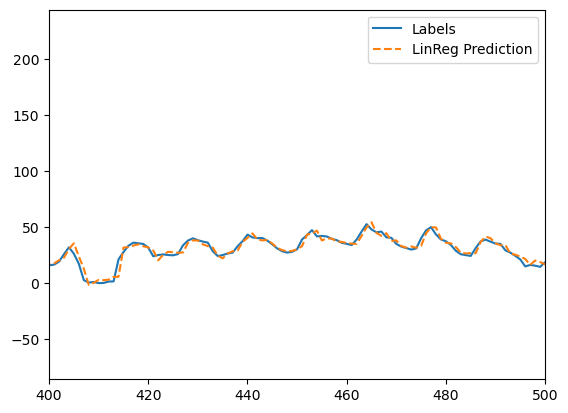

In [80]:
plt.plot(np.arange(len(y_test)), y_test[:, 0], label='Labels')
plt.plot(np.arange(len(y_test)), y_pred[:, 0], '--', alpha = 1, label='LinReg Prediction',)
plt.legend();
plt.xlim([400,500]);

In [81]:
mse = ((y_test.detach().numpy()-y_pred)**2).mean()
print(f"MSE of Linear Regression: {mse:.2f}")

MSE of Linear Regression: 34.26


### Forecast with RNN (GRU) Based Seq2Seq Model

class Seq2SeqGRU(nn.Module):
    def __init__(self, input_size=1, output_size=1, hidden_dim=32, num_layers=1, dropout=0.2):
        super(Seq2SeqGRU, self).__init__()
        self.encoder = nn.GRU(input_size,hidden_dim,batch_first=True)
        self.decoder = nn.GRU(output_size,hidden_dim,batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x_enc, y_dec):
        _, hidden = self.encoder(x_enc)
        dec_out, _ = self.decoder(y_dec, hidden)
        return self.fc(dec_out)

In [106]:
class Seq2SeqGRUtoFC(nn.Module):
    def __init__(self, input_size = 1, horizon = 1, hidden_dim = 10):
        super().__init__()
        self.encoder = nn.GRU(input_size, hidden_dim)
        #self.decoder = nn.GRU(output_size, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        out, _ = self.encoder(x)
        pred = self.decoder(out[:, -1])
        return pred

Train

In [ ]:
model = Seq2SeqGRUtoFC()

In [108]:


optimizer = torch.optim.Adam(model.parameters(), lr = 0.1)
criterion = nn.MSELoss()

for epoch in range(50):
    optimizer.zero_grad()

    pred = model(X_train.unsqueeze(-1))

    loss = criterion(pred, y_train)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.2f}')

Epoch 1, Loss: 1339.34
Epoch 2, Loss: 1269.65
Epoch 3, Loss: 1198.24
Epoch 4, Loss: 1131.69
Epoch 5, Loss: 1067.89
Epoch 6, Loss: 1006.15
Epoch 7, Loss: 946.84
Epoch 8, Loss: 890.05
Epoch 9, Loss: 835.74
Epoch 10, Loss: 783.92
Epoch 11, Loss: 734.61
Epoch 12, Loss: 687.78
Epoch 13, Loss: 643.43
Epoch 14, Loss: 601.50
Epoch 15, Loss: 561.97
Epoch 16, Loss: 524.87
Epoch 17, Loss: 489.93
Epoch 18, Loss: 457.55
Epoch 19, Loss: 427.02
Epoch 20, Loss: 398.62
Epoch 21, Loss: 374.49
Epoch 22, Loss: 347.70
Epoch 23, Loss: 325.34
Epoch 24, Loss: 309.18
Epoch 25, Loss: 285.46
Epoch 26, Loss: 268.03
Epoch 27, Loss: 256.08
Epoch 28, Loss: 237.57
Epoch 29, Loss: 227.36
Epoch 30, Loss: 217.04
Epoch 31, Loss: 205.16
Epoch 32, Loss: 192.17
Epoch 33, Loss: 184.97
Epoch 34, Loss: 176.05
Epoch 35, Loss: 165.50
Epoch 36, Loss: 159.29
Epoch 37, Loss: 151.50
Epoch 38, Loss: 141.37
Epoch 39, Loss: 137.62
Epoch 40, Loss: 133.90
Epoch 41, Loss: 124.82
Epoch 42, Loss: 122.62
Epoch 43, Loss: 118.86
Epoch 44, Loss

In [109]:
X_test.shape, prediction.shape, y_test.shape

(torch.Size([2629, 20]), torch.Size([2629, 1]), torch.Size([2629, 1]))

In [110]:
# test prediction
prediction = model(X_test.unsqueeze(dim=-1))
print(f'Predicted: {prediction[0,0].detach().numpy()}')
print(f'True Values: {y_test[0, 0].numpy()}')

Predicted: 45.732120513916016
True Values: 18.110000610351562


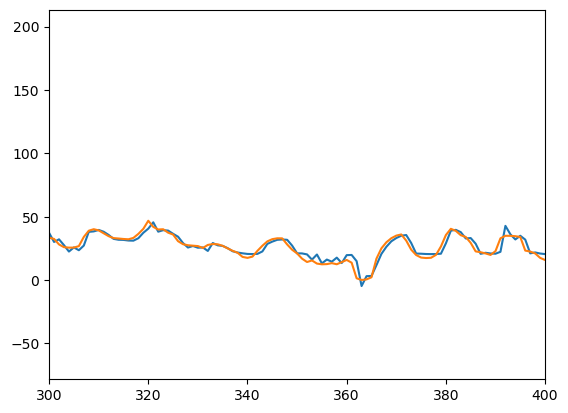

In [112]:
with torch.no_grad():
    plt.plot(prediction[:,0])
    plt.plot(y_test[:,0])
    plt.xlim([300, 400])